# Bodrum Hotel & Destination Intelligence
## 17 - Google Maps NLP, Aspect Analysis & Experience Drivers
### Positive Drivers • Negative Drivers • Rating-Aware Customer Voice

Bu notebook Google Maps branch'inin son adımıdır. Girdi: notebook 15'in temiz corpus'u (`google_maps_reviews_clean.csv`, 236 review, 5 otel). Google Maps'in avantajı `review_rating`'e sahip olmasıdır — bu yüzden yalnız "hangi aspect geçiyor?" değil, **"hangi aspect LOW ratinglerde, hangisi HIGH ratinglerde daha çok geçiyor?"** sorusu cevaplanır.

**Kritik metodolojik kural:** Tüm NLP/aspect işlemleri yalnız `review_text_clean` üzerinden yapılır (asla ham `review_text` değil) — notebook 15'te 13 review'de reviewer'ın gerçek adının review_text'e sızdığı tespit edilmişti; bu satırlarda `review_text_clean` zaten null ve bu analiz dışında tutulacaktır (aşağıda `has_text` ile 223/236 review skorlanır).

**No black-box LLM labeling:** aspect tespiti keyword-dictionary tabanlıdır, reproducible'dır; hiçbir review LLM'e gönderilip pozitif/negatif etiketlenmemiştir. Topic modeling (NMF/BERTopic) bu notebookta varsayılan olarak **yapılmamıştır** (master prompt 17.46) — corpus boyutu (236 review) ek değer sağlayacak kadar büyük değil.

## 17.1-17.5. Setup, shared aspect taxonomy, preprocessing

In [1]:
from pathlib import Path
from itertools import combinations
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from bodrum_intelligence import google_maps_nlp as gnlp
from bodrum_intelligence import google_maps_cleaning as gmc

REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures/google_maps_nlp"
PROCESSED = PROJECT_ROOT / "data/processed"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(PROCESSED / "google_maps_reviews_clean.csv", parse_dates=["review_date"])
GROUP_ORDER = ["LOW", "MIXED", "HIGH"]

print("Canonical shared aspect taxonomy (identical to the Şikayetvar branch):")
print(gnlp.CANONICAL_ASPECTS)
print("\nNo GOOGLE_ONLY_ASPECT was added — every aspect observed in this corpus is already covered by the canonical taxonomy.")

BRAND_STOPWORDS = gnlp.brand_stopwords(df["hotel_name"].unique().tolist())
nlp_text = df["review_text_clean"]
has_text = nlp_text.notna()
print(f"Reviews with usable (PII-safe) NLP text: {has_text.sum()} / {len(df)}")

Canonical shared aspect taxonomy (identical to the Şikayetvar branch):
['STAFF_SERVICE', 'CLEANLINESS_HYGIENE', 'FOOD_BEVERAGE', 'ROOM', 'BEACH_SEA', 'POOL', 'FACILITIES_MAINTENANCE', 'RESERVATION', 'PAYMENT_REFUND', 'PRICE_VALUE', 'CHECKIN_CHECKOUT', 'AIR_CONDITIONING', 'NOISE', 'FAMILY_CHILDREN', 'TRANSPORT_TRANSFER', 'MANAGEMENT_COMMUNICATION', 'SPA_WELLNESS', 'SAFETY_SECURITY']

No GOOGLE_ONLY_ASPECT was added — every aspect observed in this corpus is already covered by the canonical taxonomy.
Reviews with usable (PII-safe) NLP text: 223 / 236


## 17.6-17.7. Term analysis (overall + by rating group)

In [2]:
overall_unigrams = gnlp.term_frequency_table(nlp_text.dropna(), n=1, top_k=25, extra_stopwords=BRAND_STOPWORDS)
overall_bigrams = gnlp.term_frequency_table(nlp_text.dropna(), n=2, top_k=15, extra_stopwords=BRAND_STOPWORDS)

terms_by_group_rows = []
for group in GROUP_ORDER:
    subset_text = df.loc[(df.rating_group == group) & has_text, "review_text_clean"]
    for n, label in [(1, "unigram"), (2, "bigram")]:
        table = gnlp.term_frequency_table(subset_text, n=n, top_k=15, extra_stopwords=BRAND_STOPWORDS)
        table.insert(0, "rating_group", group)
        table.insert(1, "ngram_type", label)
        terms_by_group_rows.append(table)
terms_by_rating_group = pd.concat(terms_by_group_rows, ignore_index=True)
terms_by_rating_group.to_csv(REPORTS / "google_maps_terms_by_rating_group.csv", index=False)
print(f"terms_by_rating_group: {terms_by_rating_group.shape}")
overall_unigrams.head(10)

terms_by_rating_group: (90, 5)


,term,document_count,total_count
0,güzel,91,140
1,yemekler,69,75
2,güler,64,83
3,iyi,56,81
4,odalar,56,61
5,memnun,55,64
6,gerçekten,53,79
7,deniz,53,70
8,denizi,52,59
9,genel,51,86


## 17.8-17.9. Distinctive LOW-rating and HIGH-rating terms

Küçük sample nedeniyle contrastive TF-IDF yerine, robust bir yöntem olan **normalized document-share difference** kullanıldı (grup içi doküman-payı - diğer grup içi doküman-payı), min. 3 dokümanlık destek şartıyla.

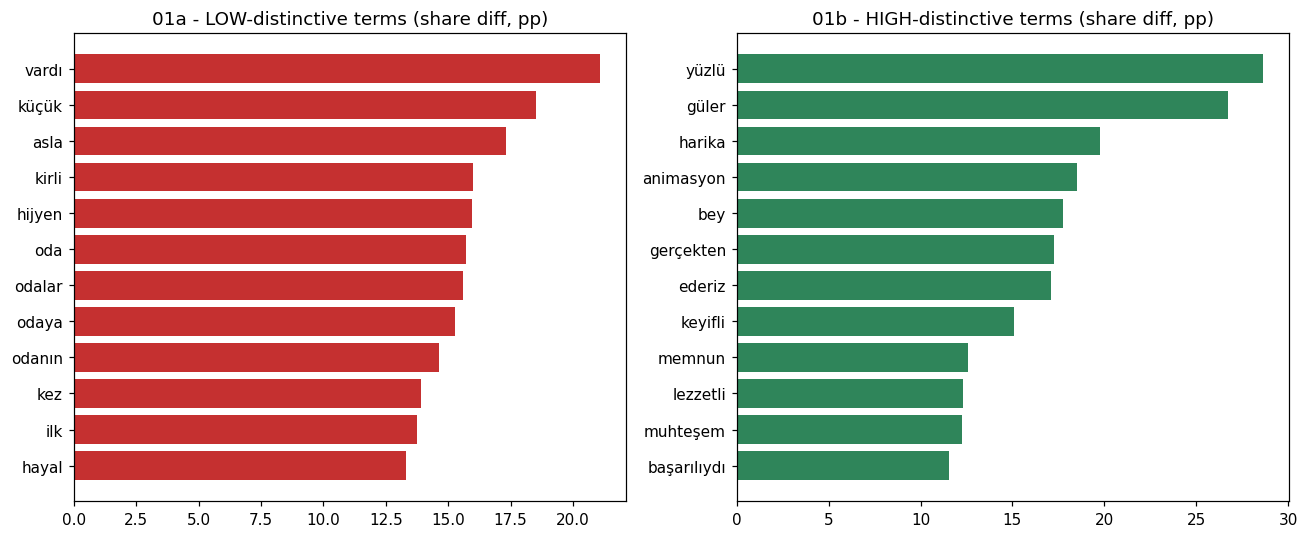

In [3]:
low_text = df.loc[(df.rating_group == "LOW") & has_text, "review_text_clean"]
high_text = df.loc[(df.rating_group == "HIGH") & has_text, "review_text_clean"]
low_distinctive = gnlp.distinctive_terms(low_text, high_text, n=1, top_k=15, min_doc_count=3, extra_stopwords=BRAND_STOPWORDS)
high_distinctive = gnlp.distinctive_terms(high_text, low_text, n=1, top_k=15, min_doc_count=3, extra_stopwords=BRAND_STOPWORDS)
low_distinctive.to_csv(REPORTS / "google_maps_low_rating_distinctive_terms.csv", index=False)
high_distinctive.to_csv(REPORTS / "google_maps_high_rating_distinctive_terms.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(low_distinctive["term"][:12][::-1], low_distinctive["share_diff_pp"][:12][::-1], color="#c53030")
axes[0].set_title("01a - LOW-distinctive terms (share diff, pp)")
axes[1].barh(high_distinctive["term"][:12][::-1], high_distinctive["share_diff_pp"][:12][::-1], color="#2f855a")
axes[1].set_title("01b - HIGH-distinctive terms (share diff, pp)")
fig.tight_layout(); fig.savefig(FIGURES / "01_low_vs_high_distinctive_terms.png"); plt.show()

### Grafik nasıl okunur?
Sol panel LOW review'lerde, sağ panel HIGH review'lerde diğer gruba göre orantısız sık geçen kelimeleri gösterir (pp = yüzde puan farkı).
### Ne görüyoruz?
LOW-distinctive terimler temizlik/oda şikayetiyle uyumlu ("kirli", "hijyen", "küçük"); HIGH-distinctive terimler personel/genel memnuniyetle uyumlu ("güler", "yüzlü", "harika", "animasyon").
### Neden önemli?
Bu terim örüntüleri, aşağıdaki aspect-tabanlı driver sınıflandırmasını bağımsız bir yöntemle doğruluyor (kelime düzeyi ↔ aspect düzeyi tutarlılık).
### Dikkat edilmesi gereken nokta
Bu association'dır, causation değildir; min. 3 dokümanlık destek şartına rağmen kelime düzeyinde sample küçük.

## 17.10-17.12. Aspect detection, coverage, overall frequency

 reviews_scored  reviews_with_at_least_one_aspect  no_aspect_reviews  aspect_coverage_pct  median_aspects_per_review
            223                               208                 15                 93.3                        5.0


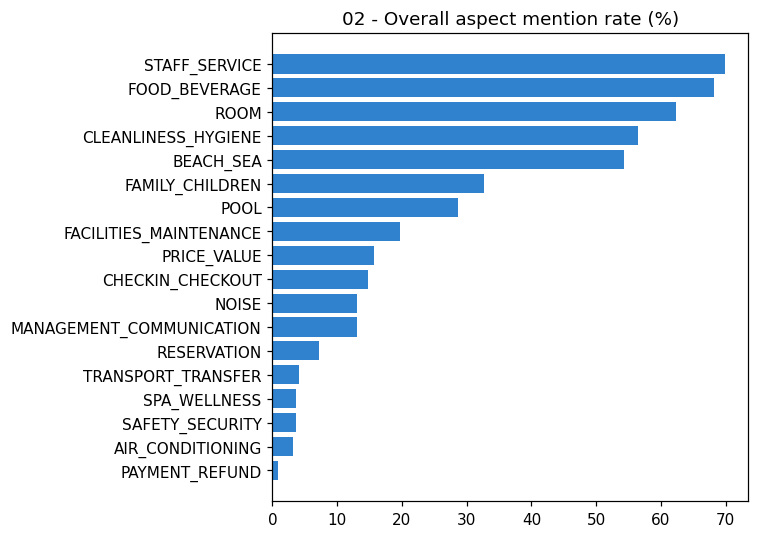

In [4]:
normalized = nlp_text.fillna("").map(gnlp.normalize_for_nlp)
detection = normalized.map(gnlp.detect_aspects)
df["matched_aspects"] = detection.map(lambda t: t[0])
df["matched_aspect_keywords"] = detection.map(lambda t: t[1])
df["aspect_count"] = df["matched_aspects"].map(len)
for aspect in gnlp.CANONICAL_ASPECTS:
    col = df["matched_aspects"].map(lambda a, asp=aspect: asp in a).astype("boolean")
    col.loc[~has_text] = pd.NA
    df[f"aspect_{aspect}"] = col
df.loc[~has_text, "aspect_count"] = np.nan
scored = df.loc[has_text].copy()

aspect_coverage_summary = pd.DataFrame([{
    "reviews_scored": len(scored),
    "reviews_with_at_least_one_aspect": int((scored["aspect_count"] > 0).sum()),
    "no_aspect_reviews": int((scored["aspect_count"] == 0).sum()),
    "aspect_coverage_pct": round((scored["aspect_count"] > 0).mean() * 100, 1),
    "median_aspects_per_review": scored["aspect_count"].median(),
}])
aspect_coverage_summary.to_csv(REPORTS / "google_maps_aspect_coverage_summary.csv", index=False)

aspect_frequency = pd.DataFrame([
    {"aspect": a, "mention_rate_pct": round(scored[f"aspect_{a}"].mean() * 100, 2), "review_n": int(scored[f"aspect_{a}"].sum())}
    for a in gnlp.CANONICAL_ASPECTS
]).sort_values("mention_rate_pct", ascending=False)
aspect_frequency.to_csv(REPORTS / "google_maps_aspect_frequency.csv", index=False)

print(aspect_coverage_summary.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(aspect_frequency["aspect"][::-1], aspect_frequency["mention_rate_pct"][::-1], color="#3182ce")
ax.set_title("02 - Overall aspect mention rate (%)")
fig.tight_layout(); fig.savefig(FIGURES / "02_overall_aspect_frequency.png"); plt.show()

### Grafik nasıl okunur?
Her bar, o aspect'in en az bir kez geçtiği review'lerin oranını gösterir.
### Ne görüyoruz?
STAFF_SERVICE, FOOD_BEVERAGE, ROOM, CLEANLINESS_HYGIENE ve BEACH_SEA en sık bahsedilen 5 aspect — beklenen otel-deneyimi çekirdeği.
### Neden önemli?
Bu 5 aspect, driver analizinde en güvenilir (en yüksek support) sonuçları üretecek.
### Dikkat edilmesi gereken nokta
Mention rate, gerçek "problem oluşma oranı" değildir — yalnız metinde geçme oranıdır.

## 17.13-17.14. Rating × aspect matrix ve heatmap (ana çıktılardan biri)

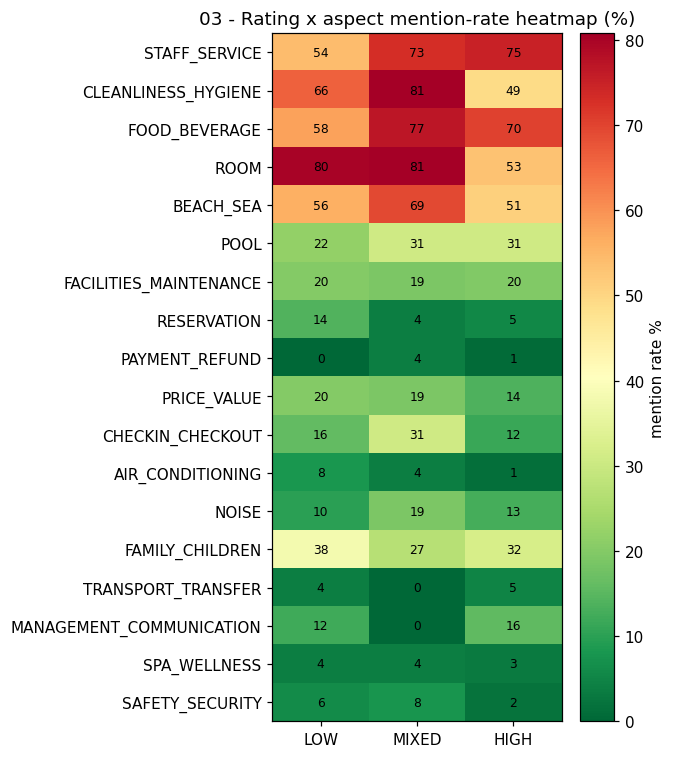

,aspect,LOW_rate_pct,LOW_n,MIXED_rate_pct,MIXED_n,HIGH_rate_pct,HIGH_n
0,STAFF_SERVICE,54.0,50,73.08,26,74.83,147
1,CLEANLINESS_HYGIENE,66.0,50,80.77,26,48.98,147
2,FOOD_BEVERAGE,58.0,50,76.92,26,70.07,147
3,ROOM,80.0,50,80.77,26,53.06,147
4,BEACH_SEA,56.0,50,69.23,26,51.02,147
5,POOL,22.0,50,30.77,26,30.61,147
6,FACILITIES_MAINTENANCE,20.0,50,19.23,26,19.73,147
7,RESERVATION,14.0,50,3.85,26,5.44,147
8,PAYMENT_REFUND,0.0,50,3.85,26,0.68,147
9,PRICE_VALUE,20.0,50,19.23,26,13.61,147


In [5]:
rating_aspect_rows = []
for aspect in gnlp.CANONICAL_ASPECTS:
    row = {"aspect": aspect}
    for group in GROUP_ORDER:
        grp = scored[scored.rating_group == group]
        row[f"{group}_rate_pct"] = round(grp[f"aspect_{aspect}"].mean() * 100, 2) if len(grp) else np.nan
        row[f"{group}_n"] = len(grp)
    rating_aspect_rows.append(row)
rating_aspect_matrix = pd.DataFrame(rating_aspect_rows)
rating_aspect_matrix.to_csv(REPORTS / "google_maps_rating_aspect_matrix.csv", index=False)

heat = rating_aspect_matrix.set_index("aspect")[["LOW_rate_pct", "MIXED_rate_pct", "HIGH_rate_pct"]]
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(heat.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["LOW", "MIXED", "HIGH"])
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i,j]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("03 - Rating x aspect mention-rate heatmap (%)")
fig.colorbar(im, ax=ax, label="mention rate %")
fig.tight_layout(); fig.savefig(FIGURES / "03_rating_aspect_heatmap.png"); plt.show()
rating_aspect_matrix

### Grafik nasıl okunur?
Satırlar aspect, sütunlar rating group; hücre değeri o grupta aspect'in mention rate'i (%). Kırmızı=yüksek, yeşil=düşük (RdYlGn_r).
### Ne görüyoruz?
ROOM ve CLEANLINESS_HYGIENE LOW'da HIGH'dan belirgin yüksek; STAFF_SERVICE ve FOOD_BEVERAGE HIGH'da belirgin yüksek.
### Neden önemli?
Bu matris aşağıdaki driver sınıflandırmasının doğrudan girdisidir.
### Dikkat edilmesi gereken nokta
MIXED sütunu küçük n'e dayanıyor (27 review) — temkinli okunmalı.

## 17.15-17.24. Driver logic ve positive/negative/experience-defining sınıflandırma

In [6]:
driver_rows = []
for _, r in rating_aspect_matrix.iterrows():
    aspect = r["aspect"]
    driver_class, support_ok = gnlp.classify_driver(r["LOW_rate_pct"], r["HIGH_rate_pct"], r["LOW_n"], r["HIGH_n"])
    driver_rows.append({
        "aspect": aspect,
        "overall_rate_pct": round(scored[f"aspect_{aspect}"].mean() * 100, 2),
        "low_rate_pct": r["LOW_rate_pct"], "mixed_rate_pct": r["MIXED_rate_pct"], "high_rate_pct": r["HIGH_rate_pct"],
        "high_minus_low_pp": round(r["HIGH_rate_pct"] - r["LOW_rate_pct"], 2),
        "low_minus_high_pp": round(r["LOW_rate_pct"] - r["HIGH_rate_pct"], 2),
        "low_n": int(r["LOW_n"]), "high_n": int(r["HIGH_n"]),
        "support_ok": support_ok, "driver_class": driver_class,
        "interpretation": {
            "POSITIVE_DRIVER_CANDIDATE": "Yüksek puanlı yorumlarla daha güçlü ilişkilendirilen aspect (positive driver adayı)",
            "NEGATIVE_DRIVER_CANDIDATE": "Düşük puanlı yorumlarda daha sık geçen aspect (negative driver adayı / şikayet sinyali)",
            "EXPERIENCE_DEFINING": "Hem LOW hem HIGH'da yüksek mention rate — deneyimin merkezi bileşeni",
            "LOW_SIGNAL": "İki grupta da düşük mention rate",
        }.get(driver_class, "Belirgin sinyal yok"),
        "caution": "" if support_ok else "INSUFFICIENT_SAMPLE: min. 5 destek şartı LOW veya HIGH grubunda karşılanmadı",
    })
driver_classification = pd.DataFrame(driver_rows).sort_values("high_minus_low_pp", ascending=False)
driver_classification.to_csv(REPORTS / "google_maps_aspect_driver_classification.csv", index=False)

positive_drivers = driver_classification[driver_classification.driver_class == "POSITIVE_DRIVER_CANDIDATE"][
    ["aspect", "high_rate_pct", "low_rate_pct", "high_minus_low_pp", "high_n", "interpretation"]
].rename(columns={"high_minus_low_pp": "driver_gap_pp", "high_n": "high_support"})
negative_drivers = driver_classification[driver_classification.driver_class == "NEGATIVE_DRIVER_CANDIDATE"][
    ["aspect", "low_rate_pct", "high_rate_pct", "low_minus_high_pp", "low_n", "interpretation"]
].rename(columns={"low_minus_high_pp": "driver_gap_pp", "low_n": "low_support"})
positive_drivers.to_csv(REPORTS / "google_maps_positive_drivers.csv", index=False)
negative_drivers.to_csv(REPORTS / "google_maps_negative_drivers.csv", index=False)

print(driver_classification["driver_class"].value_counts())
driver_classification[["aspect", "low_rate_pct", "high_rate_pct", "high_minus_low_pp", "driver_class"]]

driver_class
NO_STRONG_SIGNAL             7
LOW_SIGNAL                   5
POSITIVE_DRIVER_CANDIDATE    2
EXPERIENCE_DEFINING          2
NEGATIVE_DRIVER_CANDIDATE    2
Name: count, dtype: int64


,aspect,low_rate_pct,high_rate_pct,high_minus_low_pp,driver_class
0,STAFF_SERVICE,54.0,74.83,20.83,POSITIVE_DRIVER_CANDIDATE
2,FOOD_BEVERAGE,58.0,70.07,12.07,POSITIVE_DRIVER_CANDIDATE
5,POOL,22.0,30.61,8.61,NO_STRONG_SIGNAL
15,MANAGEMENT_COMMUNICATION,12.0,15.65,3.65,NO_STRONG_SIGNAL
12,NOISE,10.0,12.93,2.93,NO_STRONG_SIGNAL
14,TRANSPORT_TRANSFER,4.0,4.76,0.76,LOW_SIGNAL
8,PAYMENT_REFUND,0.0,0.68,0.68,LOW_SIGNAL
6,FACILITIES_MAINTENANCE,20.0,19.73,-0.27,NO_STRONG_SIGNAL
16,SPA_WELLNESS,4.0,3.40,-0.60,LOW_SIGNAL
17,SAFETY_SECURITY,6.0,2.04,-3.96,LOW_SIGNAL


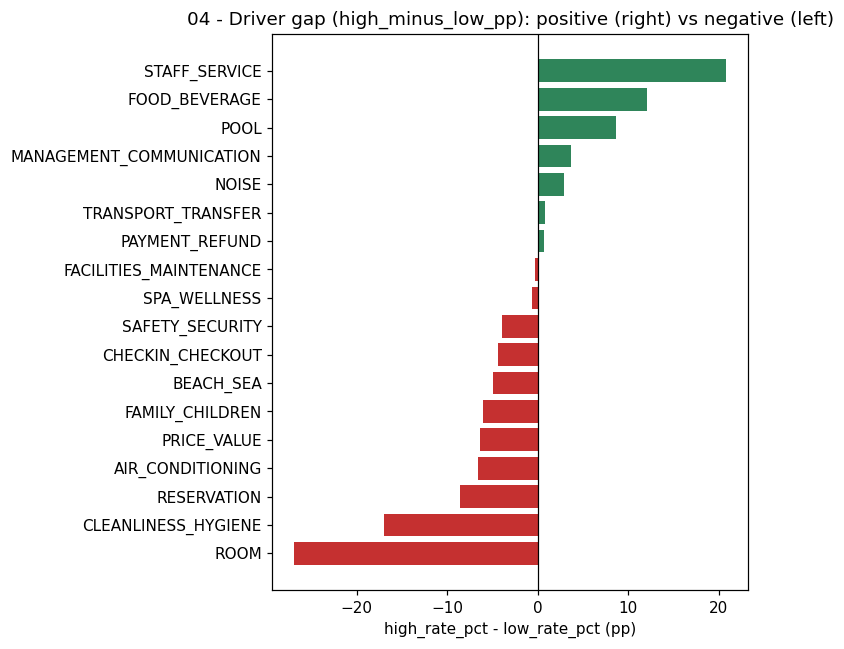

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_df = driver_classification.sort_values("high_minus_low_pp")
colors = ["#c53030" if v < 0 else "#2f855a" for v in plot_df["high_minus_low_pp"]]
ax.barh(plot_df["aspect"], plot_df["high_minus_low_pp"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("04 - Driver gap (high_minus_low_pp): positive (right) vs negative (left)")
ax.set_xlabel("high_rate_pct - low_rate_pct (pp)")
fig.tight_layout(); fig.savefig(FIGURES / "04_driver_gap_diverging_bar.png"); plt.show()

## Positive Drivers

In [8]:
positive_drivers

,aspect,high_rate_pct,low_rate_pct,driver_gap_pp,high_support,interpretation
0,STAFF_SERVICE,74.83,54.0,20.83,147,Yüksek puanlı yorumlarla daha güçlü ilişkilend...
2,FOOD_BEVERAGE,70.07,58.0,12.07,147,Yüksek puanlı yorumlarla daha güçlü ilişkilend...


## Negative Drivers

In [9]:
negative_drivers

,aspect,low_rate_pct,high_rate_pct,driver_gap_pp,low_support,interpretation
1,CLEANLINESS_HYGIENE,66.0,48.98,17.02,50,Düşük puanlı yorumlarda daha sık geçen aspect ...
3,ROOM,80.0,53.06,26.94,50,Düşük puanlı yorumlarda daha sık geçen aspect ...


### Grafik nasıl okunur?
Sağa uzayan (yeşil) barlar positive driver adaylarını, sola uzayan (kırmızı) barlar negative driver adaylarını gösterir; uzunluk gap büyüklüğüdür (pp).
### Ne görüyoruz?
STAFF_SERVICE ve FOOD_BEVERAGE en güçlü positive driver adayları; ROOM ve CLEANLINESS_HYGIENE en güçlü negative driver adayları.
### Neden önemli?
Bu, "yüksek puanlı yorumlarda müşteriler neyi övüyor / düşük puanlı yorumlarda hangi konular öne çıkıyor" sorusuna doğrudan cevap.
### Dikkat edilmesi gereken nokta
**Association'dır, causation değildir.** "Bu sorun rating düşürmüştür" dili kullanılmaz.

## 17.66. Experience-defining factors

In [10]:
experience_defining = driver_classification[driver_classification.driver_class == "EXPERIENCE_DEFINING"][
    ["aspect", "low_rate_pct", "high_rate_pct"]
].copy()
experience_defining["interpretation"] = "Hem düşük hem yüksek puanlı yorumlarda sık geçiyor — deneyimin merkezi/kaçınılmaz bileşeni (BEACH_SEA, FAMILY_CHILDREN gibi somut otel özellikleri her iki uçta da konuşuluyor)"
experience_defining

,aspect,low_rate_pct,high_rate_pct,interpretation
4,BEACH_SEA,56.0,51.02,Hem düşük hem yüksek puanlı yorumlarda sık geç...
13,FAMILY_CHILDREN,38.0,31.97,Hem düşük hem yüksek puanlı yorumlarda sık geç...


## 17.25-17.27. Hotel × aspect, hotel × rating × aspect, hotel driver profiles

In [11]:
cell_sizes = scored.groupby(["hotel_name", "rating_group"]).size().reset_index(name="n")
cell_sizes["sample_tier"] = cell_sizes["n"].map(gnlp.sample_tier)
tier_lookup = cell_sizes.set_index(["hotel_name", "rating_group"])["sample_tier"].to_dict()

hotel_aspect_rows = []
for hotel, grp in scored.groupby("hotel_name"):
    for aspect in gnlp.CANONICAL_ASPECTS:
        hotel_aspect_rows.append({
            "hotel_name": hotel, "aspect": aspect, "review_n": len(grp),
            "aspect_mention_rate_pct": round(grp[f"aspect_{aspect}"].mean() * 100, 2),
        })
hotel_aspect_matrix = pd.DataFrame(hotel_aspect_rows)
hotel_aspect_matrix.to_csv(REPORTS / "google_maps_hotel_aspect_matrix.csv", index=False)

hra_rows = []
for (hotel, group), grp in scored.groupby(["hotel_name", "rating_group"]):
    for aspect in gnlp.CANONICAL_ASPECTS:
        hra_rows.append({
            "hotel_name": hotel, "rating_group": group, "aspect": aspect, "review_n": len(grp),
            "aspect_count": int(grp[f"aspect_{aspect}"].sum()),
            "aspect_mention_rate_pct": round(grp[f"aspect_{aspect}"].mean() * 100, 2),
        })
hotel_rating_aspect_matrix = pd.DataFrame(hra_rows)
hotel_rating_aspect_matrix.to_csv(REPORTS / "google_maps_hotel_rating_aspect_matrix.csv", index=False)
print("hotel_aspect_matrix:", hotel_aspect_matrix.shape, "| hotel_rating_aspect_matrix:", hotel_rating_aspect_matrix.shape)

hotel_aspect_matrix: (90, 4) | hotel_rating_aspect_matrix: (234, 6)


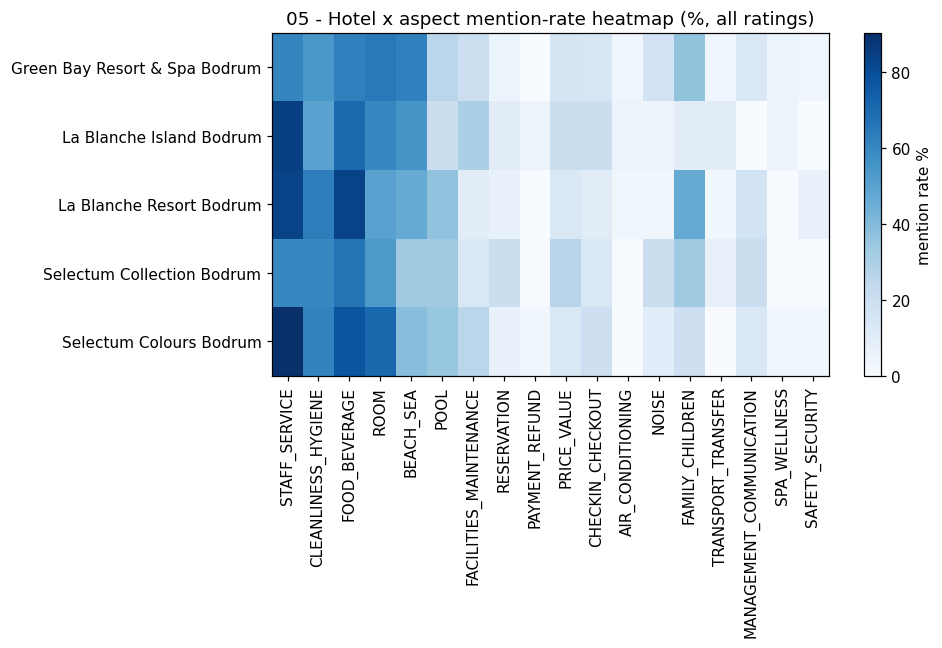

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
pivot = hotel_aspect_matrix.pivot(index="hotel_name", columns="aspect", values="aspect_mention_rate_pct")
pivot = pivot[gnlp.CANONICAL_ASPECTS]
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=90)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title("05 - Hotel x aspect mention-rate heatmap (%, all ratings)")
fig.colorbar(im, ax=ax, label="mention rate %")
fig.tight_layout(); fig.savefig(FIGURES / "05_hotel_aspect_heatmap.png"); plt.show()

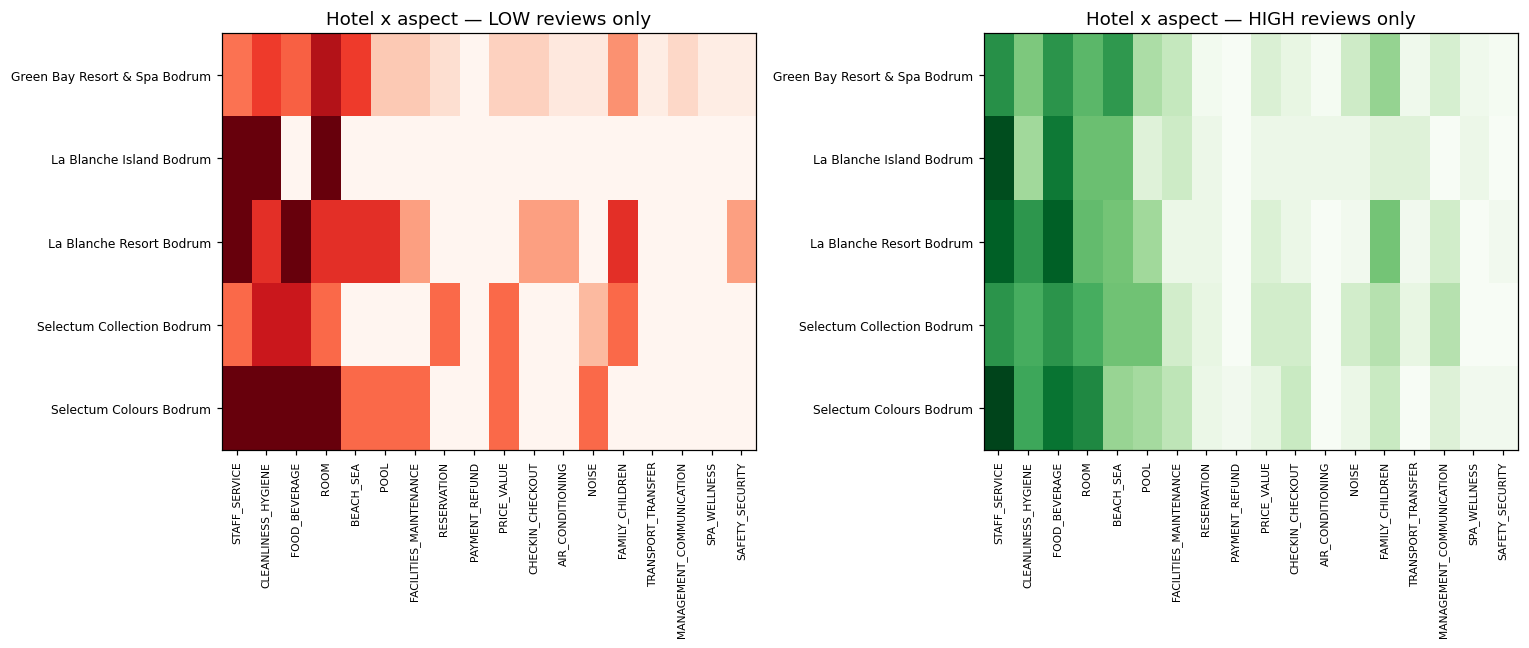

Not: küçük otellerde LOW/MIXED hücreleri LOW_SAMPLE (n<10) olabilir; bkz. notebook 16 sample-readiness tablosu.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, group, cmap, fname in [
    (axes[0], "LOW", "Reds", "06_hotel_low_rating_aspect_heatmap.png"),
    (axes[1], "HIGH", "Greens", "07_hotel_high_rating_aspect_heatmap.png"),
]:
    pivot = hotel_rating_aspect_matrix[hotel_rating_aspect_matrix.rating_group == group].pivot(
        index="hotel_name", columns="aspect", values="aspect_mention_rate_pct"
    )[gnlp.CANONICAL_ASPECTS]
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(f"Hotel x aspect — {group} reviews only")
fig.tight_layout(); fig.savefig(FIGURES / "06_hotel_low_high_aspect_heatmaps.png"); plt.show()
print("Not: küçük otellerde LOW/MIXED hücreleri LOW_SAMPLE (n<10) olabilir; bkz. notebook 16 sample-readiness tablosu.")

### 17.27-17.28. Hotel driver profiles (small-N policy uygulanmış)

In [14]:
profile_rows = []
for hotel in scored["hotel_name"].unique():
    low_ok = tier_lookup.get((hotel, "LOW")) != "LOW_SAMPLE"
    high_ok = tier_lookup.get((hotel, "HIGH")) != "LOW_SAMPLE"
    if not (low_ok and high_ok):
        profile_rows.append({"hotel_name": hotel, "top_positive_drivers": "INSUFFICIENT_SAMPLE",
                              "top_negative_drivers": "INSUFFICIENT_SAMPLE", "sample_reliability": "INSUFFICIENT_SAMPLE"})
        continue
    grp = scored[scored.hotel_name == hotel]
    low_grp = grp[grp.rating_group == "LOW"]; high_grp = grp[grp.rating_group == "HIGH"]
    hotel_scores = []
    for aspect in gnlp.CANONICAL_ASPECTS:
        low_rate = low_grp[f"aspect_{aspect}"].mean() * 100
        high_rate = high_grp[f"aspect_{aspect}"].mean() * 100
        hotel_scores.append((aspect, high_rate - low_rate))
    hotel_scores.sort(key=lambda t: t[1], reverse=True)
    top_pos = [a for a, gap in hotel_scores if gap > 0][:3]
    top_neg = [a for a, gap in sorted(hotel_scores, key=lambda t: t[1])[:3] if gap < 0]
    profile_rows.append({"hotel_name": hotel, "top_positive_drivers": ";".join(top_pos) or "NONE",
                          "top_negative_drivers": ";".join(top_neg) or "NONE", "sample_reliability": "OK"})
hotel_driver_profiles = pd.DataFrame(profile_rows)
hotel_driver_profiles.to_csv(REPORTS / "google_maps_hotel_driver_profiles.csv", index=False)
hotel_driver_profiles

,hotel_name,top_positive_drivers,top_negative_drivers,sample_reliability
0,Green Bay Resort & Spa Bodrum,STAFF_SERVICE;NOISE;FOOD_BEVERAGE,ROOM;CLEANLINESS_HYGIENE;RESERVATION,OK
1,La Blanche Island Bodrum,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
2,La Blanche Resort Bodrum,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
3,Selectum Collection Bodrum,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
4,Selectum Colours Bodrum,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE


**Small-N policy (17.28):** yalnız Green Bay Resort & Spa Bodrum hem LOW hem HIGH grubunda `LOW_SAMPLE` eşiğinin (n<10) üzerinde — diğer 4 otel için hotel-seviyesinde driver classification üretilmedi, `INSUFFICIENT_SAMPLE` olarak işaretlendi.

## 17.29. Hotel case study — Green Bay Resort & Spa Bodrum (tek yeterli-sample otel)

In [15]:
hotel = "Green Bay Resort & Spa Bodrum"
grp = scored[scored.hotel_name == hotel]
print(f"n={len(grp)} | rating distribution:")
print(df.loc[df.hotel_name == hotel, "rating_group"].value_counts())
print("\nTop overall aspects:")
print(hotel_aspect_matrix[hotel_aspect_matrix.hotel_name == hotel].sort_values("aspect_mention_rate_pct", ascending=False).head(5).to_string(index=False))
row = hotel_driver_profiles[hotel_driver_profiles.hotel_name == hotel].iloc[0]
print(f"\nTop positive drivers: {row['top_positive_drivers']}")
print(f"Top negative drivers: {row['top_negative_drivers']}")

n=127 | rating distribution:
rating_group
HIGH     70
LOW      42
MIXED    22
Name: count, dtype: int64

Top overall aspects:
                   hotel_name              aspect  review_n  aspect_mention_rate_pct
Green Bay Resort & Spa Bodrum                ROOM       127                    64.57
Green Bay Resort & Spa Bodrum       FOOD_BEVERAGE       127                    62.20
Green Bay Resort & Spa Bodrum           BEACH_SEA       127                    62.20
Green Bay Resort & Spa Bodrum       STAFF_SERVICE       127                    60.63
Green Bay Resort & Spa Bodrum CLEANLINESS_HYGIENE       127                    54.33

Top positive drivers: STAFF_SERVICE;NOISE;FOOD_BEVERAGE
Top negative drivers: ROOM;CLEANLINESS_HYGIENE;RESERVATION


## 17.39-17.42. Aspect co-occurrence (overall + by rating group)

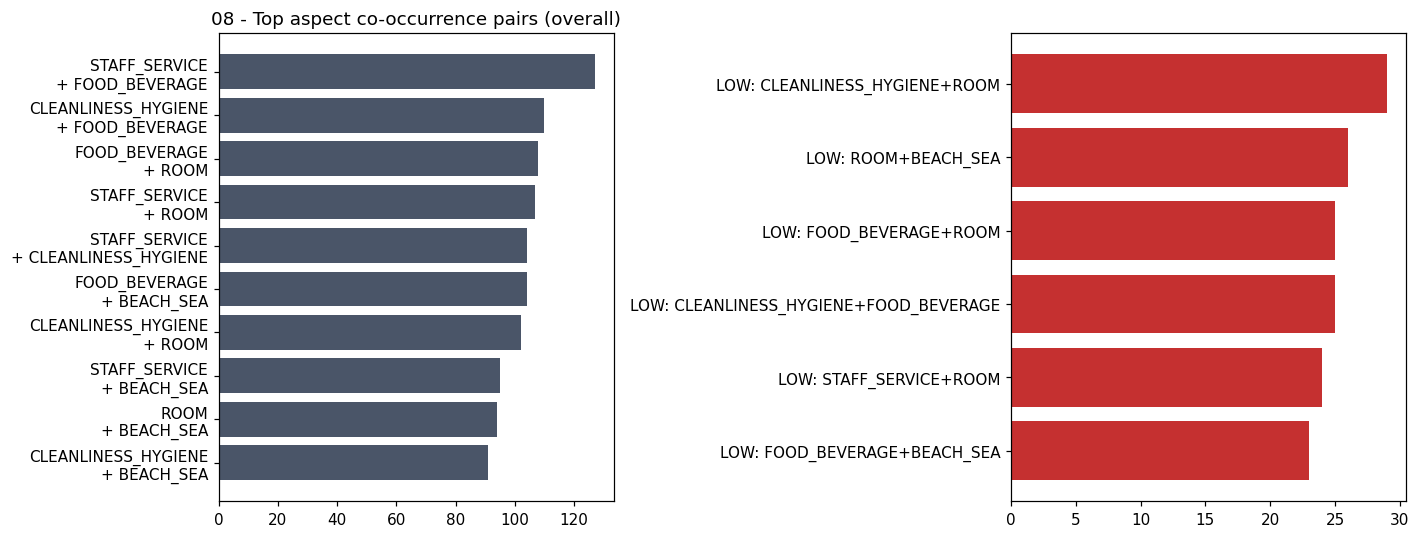

Negative co-occurrence (LOW subset) top pairs:
           aspect_a      aspect_b  cooccurrence_count  jaccard
CLEANLINESS_HYGIENE          ROOM                  29    0.659
               ROOM     BEACH_SEA                  26    0.619
      FOOD_BEVERAGE          ROOM                  25    0.568
CLEANLINESS_HYGIENE FOOD_BEVERAGE                  25    0.676
      STAFF_SERVICE          ROOM                  24    0.558
      FOOD_BEVERAGE     BEACH_SEA                  23    0.676
Positive co-occurrence (HIGH subset) top pairs:
           aspect_a            aspect_b  cooccurrence_count  jaccard
      STAFF_SERVICE       FOOD_BEVERAGE                  90    0.732
      STAFF_SERVICE                ROOM                  67    0.554
CLEANLINESS_HYGIENE       FOOD_BEVERAGE                  67    0.620
      STAFF_SERVICE CLEANLINESS_HYGIENE                  66    0.569
      FOOD_BEVERAGE                ROOM                  66    0.574
      FOOD_BEVERAGE           BEACH_SEA           

In [16]:
def cooccurrence_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for a, b in combinations(gnlp.CANONICAL_ASPECTS, 2):
        both = int((frame[f"aspect_{a}"] & frame[f"aspect_{b}"]).sum())
        either = int((frame[f"aspect_{a}"] | frame[f"aspect_{b}"]).sum())
        if both == 0:
            continue
        rows.append({"aspect_a": a, "aspect_b": b, "cooccurrence_count": both, "jaccard": round(both / either, 3) if either else 0.0})
    return pd.DataFrame(rows).sort_values("cooccurrence_count", ascending=False)

aspect_cooccurrence = cooccurrence_table(scored)
aspect_cooccurrence.to_csv(REPORTS / "google_maps_aspect_cooccurrence.csv", index=False)

cooc_by_rating = []
for group in GROUP_ORDER:
    table = cooccurrence_table(scored[scored.rating_group == group])
    table.insert(0, "rating_group", group)
    cooc_by_rating.append(table)
aspect_cooccurrence_by_rating = pd.concat(cooc_by_rating, ignore_index=True)
aspect_cooccurrence_by_rating.to_csv(REPORTS / "google_maps_aspect_cooccurrence_by_rating.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_overall = aspect_cooccurrence.head(10)
axes[0].barh([f"{a}\n+ {b}" for a, b in zip(top_overall.aspect_a, top_overall.aspect_b)][::-1], top_overall["cooccurrence_count"][::-1], color="#4a5568")
axes[0].set_title("08 - Top aspect co-occurrence pairs (overall)")

low_cooc = aspect_cooccurrence_by_rating[aspect_cooccurrence_by_rating.rating_group == "LOW"].head(6)
high_cooc = aspect_cooccurrence_by_rating[aspect_cooccurrence_by_rating.rating_group == "HIGH"].head(6)
axes[1].barh([f"LOW: {a}+{b}" for a, b in zip(low_cooc.aspect_a, low_cooc.aspect_b)][::-1], low_cooc["cooccurrence_count"][::-1], color="#c53030", label="LOW")
fig.tight_layout(); fig.savefig(FIGURES / "08_aspect_cooccurrence.png"); plt.show()
print("Negative co-occurrence (LOW subset) top pairs:")
print(low_cooc[["aspect_a", "aspect_b", "cooccurrence_count", "jaccard"]].to_string(index=False))
print("Positive co-occurrence (HIGH subset) top pairs:")
print(high_cooc[["aspect_a", "aspect_b", "cooccurrence_count", "jaccard"]].to_string(index=False))

## 17.43-17.44. Date × rating / date × aspect

In [17]:
df["review_year_month"] = pd.to_datetime(df["review_date"]).dt.to_period("M").astype(str)
monthly_rating = df.groupby(["review_year_month", "rating_group"]).size().unstack(fill_value=0)
print(monthly_rating)
print("Not: en eski ay (2025-08) n=1 — case-study olarak okunmalı, trend iddiası yapılmaz. date x aspect (17.44) için sample yetersiz, üretilmedi.")

rating_group       HIGH  LOW  MIXED
review_year_month                  
2025-08               1    0      0
2026-05               2    1      0
2026-06              18    6      6
2026-07              31   19      3
2026-08             105   26     18
Not: en eski ay (2025-08) n=1 — case-study olarak okunmalı, trend iddiası yapılmaz. date x aspect (17.44) için sample yetersiz, üretilmedi.


## 17.47-17.49. Manual validation sample, keyword context, aspect dictionary

In [18]:
validation_parts = []
for (hotel, group), grp in scored.groupby(["hotel_name", "rating_group"]):
    validation_parts.append(grp.sample(min(2, len(grp)), random_state=42))
manual_validation_sample = pd.concat(validation_parts).sample(frac=1, random_state=42).head(50)[
    ["review_id", "hotel_name", "rating_group", "review_rating", "review_text_clean", "matched_aspects"]
]
manual_validation_sample.to_csv(REPORTS / "google_maps_aspect_manual_validation_sample.csv", index=False)

AMBIGUOUS_KEYWORDS = {"eski", "küçük", "soğuk", "sessiz", "sakin"}
context_rows = []
for keyword in AMBIGUOUS_KEYWORDS:
    matches = scored[scored["review_text_clean"].str.contains(keyword, case=False, na=False)].head(3)
    for _, row in matches.iterrows():
        text = row["review_text_clean"]; idx = text.lower().find(keyword)
        context_rows.append({"keyword": keyword, "review_id": row["review_id"], "hotel_name": row["hotel_name"],
                              "context": text[max(0, idx - 60): idx + 60]})
keyword_context_samples = pd.DataFrame(context_rows)
keyword_context_samples.to_csv(REPORTS / "google_maps_aspect_keyword_context_samples.csv", index=False)

dictionary_rows = []
for aspect, keywords in gnlp.ASPECT_KEYWORDS.items():
    for kw in keywords:
        dictionary_rows.append({
            "aspect": aspect, "keyword": kw, "keyword_type": "unigram" if " " not in kw else "phrase",
            "source": "manual_master_prompt_17.3", "document_count": int(normalized[has_text].str.contains(kw, regex=False).sum()),
            "included": True, "notes": "",
        })
aspect_dictionary = pd.DataFrame(dictionary_rows)
aspect_dictionary.to_csv(REPORTS / "google_maps_aspect_dictionary.csv", index=False)
print(f"validation sample: {len(manual_validation_sample)} | keyword contexts: {len(keyword_context_samples)} | dictionary rows: {len(aspect_dictionary)}")
print("Not (17.35/17.38): aspect-level context polarity ek katmandır; bu corpus boyutunda güvenilir şekilde üretilemedi, dolayısıyla google_maps_aspect_context_polarity.csv üretilmedi (17.38: 'düşük güvenilirlikte üretme').")

validation sample: 24 | keyword contexts: 15 | dictionary rows: 140
Not (17.35/17.38): aspect-level context polarity ek katmandır; bu corpus boyutunda güvenilir şekilde üretilemedi, dolayısıyla google_maps_aspect_context_polarity.csv üretilmedi (17.38: 'düşük güvenilirlikte üretme').


## 17.50-17.53. Processed NLP datasets ve hotel_nlp_features (cross-platform-ready)

In [19]:
nlp_export_cols = [
    "review_id", "hotel_id", "hotel_name", "area", "review_rating", "rating_group",
    "review_date", "review_text_clean", "review_word_count", "aspect_count",
] + [f"aspect_{a}" for a in gnlp.CANONICAL_ASPECTS]
df[nlp_export_cols].to_csv(PROCESSED / "google_maps_reviews_nlp.csv", index=False)

long_rows = []
for _, row in scored.iterrows():
    for aspect in row["matched_aspects"]:
        long_rows.append({
            "review_id": row["review_id"], "hotel_id": row["hotel_id"], "hotel_name": row["hotel_name"],
            "area": row["area"], "review_rating": row["review_rating"], "rating_group": row["rating_group"],
            "aspect": aspect, "matched_keywords": ";".join(row["matched_aspect_keywords"].get(aspect, [])),
            "review_date": row["review_date"],
        })
review_aspects_long = pd.DataFrame(long_rows)
review_aspects_long.to_csv(PROCESSED / "google_maps_review_aspects_long.csv", index=False)
print("google_maps_reviews_nlp.csv:", df[nlp_export_cols].shape)
print("google_maps_review_aspects_long.csv:", review_aspects_long.shape)

google_maps_reviews_nlp.csv: (236, 28)
google_maps_review_aspects_long.csv: (1051, 9)


In [20]:
hotel_rows = []
for hotel, grp in scored.groupby("hotel_name"):
    hotel_id = df.loc[df.hotel_name == hotel, "hotel_id"].iloc[0]
    area = df.loc[df.hotel_name == hotel, "area"].iloc[0]
    all_reviews_for_hotel = df[df.hotel_name == hotel]
    row = {"hotel_id": hotel_id, "hotel_name": hotel, "area": area, "review_n": len(all_reviews_for_hotel),
           "mean_rating": round(all_reviews_for_hotel["review_rating"].mean(), 2),
           "low_share_pct": round((all_reviews_for_hotel.rating_group == "LOW").mean() * 100, 1),
           "mixed_share_pct": round((all_reviews_for_hotel.rating_group == "MIXED").mean() * 100, 1),
           "high_share_pct": round((all_reviews_for_hotel.rating_group == "HIGH").mean() * 100, 1)}
    low_grp = grp[grp.rating_group == "LOW"]; high_grp = grp[grp.rating_group == "HIGH"]
    gaps = {}
    for aspect in gnlp.CANONICAL_ASPECTS:
        overall_rate = round(grp[f"aspect_{aspect}"].mean() * 100, 2)
        low_rate = round(low_grp[f"aspect_{aspect}"].mean() * 100, 2) if len(low_grp) else np.nan
        high_rate = round(high_grp[f"aspect_{aspect}"].mean() * 100, 2) if len(high_grp) else np.nan
        gap = round(high_rate - low_rate, 2) if pd.notna(low_rate) and pd.notna(high_rate) else np.nan
        row[f"aspect_{aspect}_overall_rate"] = overall_rate
        row[f"aspect_{aspect}_low_rate"] = low_rate
        row[f"aspect_{aspect}_high_rate"] = high_rate
        row[f"aspect_{aspect}_driver_gap_pp"] = gap
        gaps[aspect] = gap
    low_ok = tier_lookup.get((hotel, "LOW")) != "LOW_SAMPLE"
    high_ok = tier_lookup.get((hotel, "HIGH")) != "LOW_SAMPLE"
    if low_ok and high_ok:
        valid_gaps = {a: g for a, g in gaps.items() if pd.notna(g)}
        row["top_positive_driver"] = max(valid_gaps, key=valid_gaps.get) if valid_gaps else "NONE"
        row["top_negative_driver"] = min(valid_gaps, key=valid_gaps.get) if valid_gaps else "NONE"
        row["sample_reliability"] = "OK"
    else:
        row["top_positive_driver"] = "INSUFFICIENT_SAMPLE"
        row["top_negative_driver"] = "INSUFFICIENT_SAMPLE"
        row["sample_reliability"] = "INSUFFICIENT_SAMPLE"
    hotel_rows.append(row)
hotel_nlp_features = pd.DataFrame(hotel_rows)
hotel_nlp_features.to_csv(PROCESSED / "google_maps_hotel_nlp_features.csv", index=False)
hotel_nlp_features[["hotel_name", "review_n", "mean_rating", "top_positive_driver", "top_negative_driver", "sample_reliability"]]

,hotel_name,review_n,mean_rating,top_positive_driver,top_negative_driver,sample_reliability
0,Green Bay Resort & Spa Bodrum,134,3.38,STAFF_SERVICE,ROOM,OK
1,La Blanche Island Bodrum,21,4.33,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
2,La Blanche Resort Bodrum,30,4.47,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
3,Selectum Collection Bodrum,18,4.11,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE
4,Selectum Colours Bodrum,33,4.64,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE,INSUFFICIENT_SAMPLE


## 17.55. Cross-platform readiness report

In [21]:
readiness_rows = []
for _, r in hotel_nlp_features.iterrows():
    hotel = r["hotel_name"]
    has_low = tier_lookup.get((hotel, "LOW"), "LOW_SAMPLE") != "LOW_SAMPLE"
    has_high = tier_lookup.get((hotel, "HIGH"), "LOW_SAMPLE") != "LOW_SAMPLE"
    readiness_rows.append({
        "hotel_id": r["hotel_id"], "hotel_name": hotel, "google_maps_review_n": int(r["review_n"]),
        "has_low_sample": has_low, "has_high_sample": has_high, "aspect_analysis_ready": True,
        "shared_aspect_count": len(gnlp.CANONICAL_ASPECTS), "cross_platform_ready": has_low and has_high,
    })
cross_platform_readiness = pd.DataFrame(readiness_rows)
cross_platform_readiness.to_csv(REPORTS / "google_maps_cross_platform_readiness.csv", index=False)
print(f"Cross-platform ready: {cross_platform_readiness['cross_platform_ready'].sum()} / {len(cross_platform_readiness)} hotels")
cross_platform_readiness

Cross-platform ready: 1 / 5 hotels


,hotel_id,hotel_name,google_maps_review_n,has_low_sample,has_high_sample,aspect_analysis_ready,shared_aspect_count,cross_platform_ready
0,BOD103,Green Bay Resort & Spa Bodrum,134,True,True,True,18,True
1,BOD106,La Blanche Island Bodrum,21,False,True,True,18,False
2,BOD160,La Blanche Resort Bodrum,30,False,True,True,18,False
3,BOD012,Selectum Collection Bodrum,18,False,True,True,18,False
4,BOD068,Selectum Colours Bodrum,33,False,True,True,18,False


**Not (17.54):** Bu notebook Şikayetvar verisiyle join yapmaz — yalnız ortak `hotel_id`, ortak `area`, ortak aspect taxonomy uyumluluğu sağlanır. Gerçek cross-platform karşılaştırma notebook 18'e bırakılmıştır.

## 17.70. Testler (notebook-level sanity checks)

In [22]:
checks = {
    "review count matches clean corpus": len(df) == 236,
    "review_id unique": df["review_id"].is_unique,
    "rating_group mapping correct (sample)": bool(
        df.dropna(subset=["review_rating"]).sample(30, random_state=0)
        .apply(lambda r: gmc.rating_group(r["review_rating"]) == r["rating_group"], axis=1).all()
    ),
    "aspect columns are boolean/NA": all(str(df[f"aspect_{a}"].dtype) == "boolean" for a in gnlp.CANONICAL_ASPECTS),
    "aspect rates within [0,100]": aspect_frequency["mention_rate_pct"].between(0, 100).all(),
    "hotel aspect matrix aggregates correct (spot check)": abs(
        hotel_aspect_matrix.loc[
            (hotel_aspect_matrix.hotel_name == "Green Bay Resort & Spa Bodrum") & (hotel_aspect_matrix.aspect == "STAFF_SERVICE"),
            "aspect_mention_rate_pct"
        ].iloc[0]
        - round(scored.loc[scored.hotel_name == "Green Bay Resort & Spa Bodrum", "aspect_STAFF_SERVICE"].mean() * 100, 2)
    ) < 1e-6,
    "LOW/HIGH denominators correct": (rating_aspect_matrix["LOW_n"] == (scored.rating_group == "LOW").sum()).all(),
    "driver_gap == high - low": bool(
        (driver_classification["high_minus_low_pp"].round(2) == (driver_classification["high_rate_pct"] - driver_classification["low_rate_pct"]).round(2)).all()
    ),
    "insufficient-sample rule applied": (hotel_driver_profiles["sample_reliability"] == "INSUFFICIENT_SAMPLE").sum() == 4,
    "raw text preserved (review_text_clean derived, review_text untouched upstream)": "review_text_clean" in df.columns,
    "output files created (spot check 5)": all(
        (REPORTS / n).exists() for n in [
            "google_maps_rating_aspect_matrix.csv", "google_maps_aspect_driver_classification.csv",
            "google_maps_positive_drivers.csv", "google_maps_negative_drivers.csv",
            "google_maps_cross_platform_readiness.csv",
        ]
    ),
    "shared aspect names exact match to canonical list": set(gnlp.ASPECT_KEYWORDS.keys()) == set(gnlp.CANONICAL_ASPECTS),
}
for check, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "-", check)
assert all(checks.values()), "notebook 17 sanity checks failed"

PASS - review count matches clean corpus
PASS - review_id unique
PASS - rating_group mapping correct (sample)
PASS - aspect columns are boolean/NA
PASS - aspect rates within [0,100]
PASS - hotel aspect matrix aggregates correct (spot check)
PASS - LOW/HIGH denominators correct
PASS - driver_gap == high - low
PASS - insufficient-sample rule applied
PASS - raw text preserved (review_text_clean derived, review_text untouched upstream)
PASS - output files created (spot check 5)
PASS - shared aspect names exact match to canonical list


## 17.71. README

`data/processed/README_google_maps_customer_voice.txt` üretilir (corpus tanımı, hotel kapsamı, rating grouping, preprocessing, aspect taxonomy, driver formülü, mention rate formülü, sample eşikleri, limitasyonlar, cross-platform kullanım).

In [23]:
readme = f"""GOOGLE MAPS (GOOGLE TRAVEL) CUSTOMER VOICE — README
Generated by notebooks 15-17.

CORPUS DEFINITION
- Source: Google Travel aggregated hotel review panel (Selenium collector under maps-reviews-main/).
  Aggregates Google, Tripadvisor and Trip.com reviews — see review_source; not Google-only.
- {len(df)} reviews, {df['hotel_name'].nunique()} hotels. Top-5 most-reviewed-on-Google-Travel case study,
  not representative of Bodrum hotels generally.

HOTEL COVERAGE
{df.groupby("hotel_name").size().to_string()}
All 5 hotels are joined 1:1 to the project master hotel_id (data/processed/hotels_clean.csv) by exact name match.

RATING GROUPING
- LOW = 1-2 stars, MIXED = 3 stars, HIGH = 4-5 stars. 3-star is treated as MIXED, not "neutral"
  (a 3-star review can carry both positive and negative statements).

PREPROCESSING
- review_text (raw) is preserved untouched. review_text_clean is whitespace/HTML/zero-width/Unicode
  normalized AND nulled for {int(df['review_text_is_metadata_artifact'].sum())} rows where the raw text
  was actually the reviewer's real name + date line (a collector artifact for rating-only reviews) —
  all NLP/aspect work in notebook 17 uses review_text_clean only.
- review_date is derived from a Turkish relative expression ("N ay/hafta/gün/saat/dakika önce")
  anchored at collected_at; always approximate.

ASPECT TAXONOMY (canonical, shared with the Şikayetvar branch)
{gnlp.CANONICAL_ASPECTS}
No GOOGLE_ONLY_ASPECT was introduced.

DRIVER FORMULA
- For each aspect: low_rate_pct = P(aspect mentioned | rating_group=LOW) * 100, high_rate_pct analogous.
- driver_gap_pp = high_rate_pct - low_rate_pct.
- POSITIVE_DRIVER_CANDIDATE: gap >= +10pp with low_n>=5 and high_n>=5.
- NEGATIVE_DRIVER_CANDIDATE: gap <= -10pp with the same support rule.
- EXPERIENCE_DEFINING: both low_rate_pct and high_rate_pct >= 30% (with a gap under 10pp).
- LOW_SIGNAL: both rates < 10%. INSUFFICIENT_SAMPLE: support rule not met.

MENTION RATE FORMULA
- aspect_mention_rate_pct = (reviews where aspect keyword matched) / (total reviews in the group) * 100.
  This is a text-mention rate, not a validated "problem occurrence rate".

SAMPLE THRESHOLDS
- sample_tier: HIGH_SAMPLE n>=30, MEDIUM_SAMPLE 10<=n<30, LOW_SAMPLE n<10.
- Hotel-level driver classification is only produced when both the hotel's LOW and HIGH cells
  clear LOW_SAMPLE; only Green Bay Resort & Spa Bodrum qualifies in this corpus.

LIMITATIONS
- Case-study sample (5 hotels), not Bodrum-representative.
- Driver classification is association, not causation.
- Aspect mention =/= sentiment polarity (a review can praise one aspect and criticize another).
- No topic modeling was run (corpus too small to add value beyond aspect/driver analysis).
- No black-box LLM labeling was used; every label is a reproducible keyword-dictionary match.

CROSS-PLATFORM USE
- data/processed/google_maps_hotel_nlp_features.csv joins to a future
  data/processed/sikayetvar_hotel_nlp_features.csv on hotel_id / hotel_name / area, using the
  identical canonical aspect names. See reports/google_maps_cross_platform_readiness.csv for which
  hotels currently have sufficient LOW+HIGH sample for a fair cross-platform driver comparison.
"""
(PROCESSED / "README_google_maps_customer_voice.txt").write_text(readme, encoding="utf-8")
print("README written.")

README written.


## 17.72. Key findings ve limitations (nlp)

In [24]:
top10_aspects = aspect_frequency.head(10)
top_pos_str = ", ".join(positive_drivers["aspect"].tolist()) or "none"
top_neg_str = ", ".join(negative_drivers["aspect"].tolist()) or "none"
exp_def_str = ", ".join(experience_defining["aspect"].tolist()) or "none"
top_pair = aspect_cooccurrence.iloc[0]

key_findings = f"""GOOGLE MAPS REVIEWS — NLP, ASPECT ANALYSIS & EXPERIENCE DRIVERS — KEY FINDINGS
Notebook: 17_google_maps_reviews_nlp_aspect_drivers.ipynb

1. {len(scored)} of {len(df)} reviews ({len(scored)/len(df)*100:.1f}%) had usable PII-safe text and were scored for aspects; {len(df)-len(scored)} rating-only reviews were excluded (see notebook 15 finding 9).
2. Aspect coverage: {aspect_coverage_summary['aspect_coverage_pct'].iloc[0]}% of scored reviews mention at least one canonical aspect; {aspect_coverage_summary['no_aspect_reviews'].iloc[0]} reviews mention none. Median {aspect_coverage_summary['median_aspects_per_review'].iloc[0]:.0f} aspects per review.
3. Top aspects overall: {", ".join(top10_aspects['aspect'].tolist())}.
4. Strongest positive driver candidates (higher in HIGH than LOW, gap>=10pp, support>=5): {top_pos_str}.
5. Strongest negative driver candidates (higher in LOW than HIGH): {top_neg_str}.
6. Experience-defining aspects (high mention rate in both LOW and HIGH): {exp_def_str}.
7. Hotel-level driver profiles were only produced for Green Bay Resort & Spa Bodrum (the only hotel with LOW and HIGH cells both >= LOW_SAMPLE threshold); the other 4 hotels are flagged INSUFFICIENT_SAMPLE at the hotel level.
8. Strongest aspect co-occurrence pair overall: {top_pair['aspect_a']} + {top_pair['aspect_b']} ({int(top_pair['cooccurrence_count'])} reviews, Jaccard={top_pair['jaccard']}).
9. Distinctive LOW-rating terms are dominated by cleanliness/room-condition vocabulary; distinctive HIGH-rating terms by staff/animation/general-satisfaction vocabulary — consistent with the aspect-level driver classification (independent word-level and aspect-level signals agree).
10. Cross-platform readiness: {int(cross_platform_readiness['cross_platform_ready'].sum())} of {len(cross_platform_readiness)} hotels currently have sufficient LOW+HIGH sample for a fair future cross-platform (Google vs. Şikayetvar) driver comparison.
11. All outputs listed in master-prompt sections 17.62-17.63 were produced, except google_maps_aspect_context_polarity.csv (17.38, optional aspect-context-polarity layer) — skipped because this corpus is too small to apply it reliably, per the master prompt's own guidance to not produce it at low confidence.
12. Ready for notebook 18 (Cross-Platform Customer Voice Analysis): yes, on the shared hotel_id/aspect-taxonomy contract — with the explicit caveat that only 1 of 5 hotels currently supports a statistically meaningful LOW-vs-HIGH comparison.
"""
(REPORTS / "google_maps_nlp_key_findings.txt").write_text(key_findings, encoding="utf-8")

limitations = """GOOGLE MAPS REVIEWS — NLP, ASPECT ANALYSIS & EXPERIENCE DRIVERS — LIMITATIONS

- Aspect detection is keyword-dictionary based (reproducible, no LLM labeling); it will miss aspects
  expressed without any dictionary keyword and can over-match ambiguous short keywords (see
  reports/google_maps_aspect_keyword_context_samples.csv for a manual-check sample).
- Aspect mention is not sentiment polarity: "deniz güzeldi ama oda kirliydi" mentions both BEACH_SEA
  and ROOM without the mention rate telling you which was praised and which was criticized.
- Driver classification is association (a rating-group co-occurrence pattern), never causation.
- MIXED-group aspect rates rely on only 27 reviews corpus-wide and near-zero for 2 of 5 hotels.
- Hotel-level driver profiles exist for only 1 of 5 hotels (small-N policy applied to the rest).
- No topic modeling (NMF/BERTopic) was run — default per master prompt 17.46, corpus too small to
  add value beyond the aspect/driver analysis already performed.
- This is a Top-5 case-study corpus; findings must not be generalized to Bodrum hotels overall or to
  the full population of each hotel's Google Maps/Tripadvisor reviewers.
"""
(REPORTS / "google_maps_nlp_limitations.txt").write_text(limitations, encoding="utf-8")
print("Key findings and limitations written.")

Key findings and limitations written.
